# Stage 4: Exploratory Data Analysis (EDA)

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('./data/processed/water_potability_cleaned.csv')
feature_cols = [c for c in df.columns if c != 'Potability']
print(f'Loaded cleaned data: {df.shape}')

Loaded cleaned data: (3276, 10)


## 4.1 Univariate Analysis — Feature Distributions

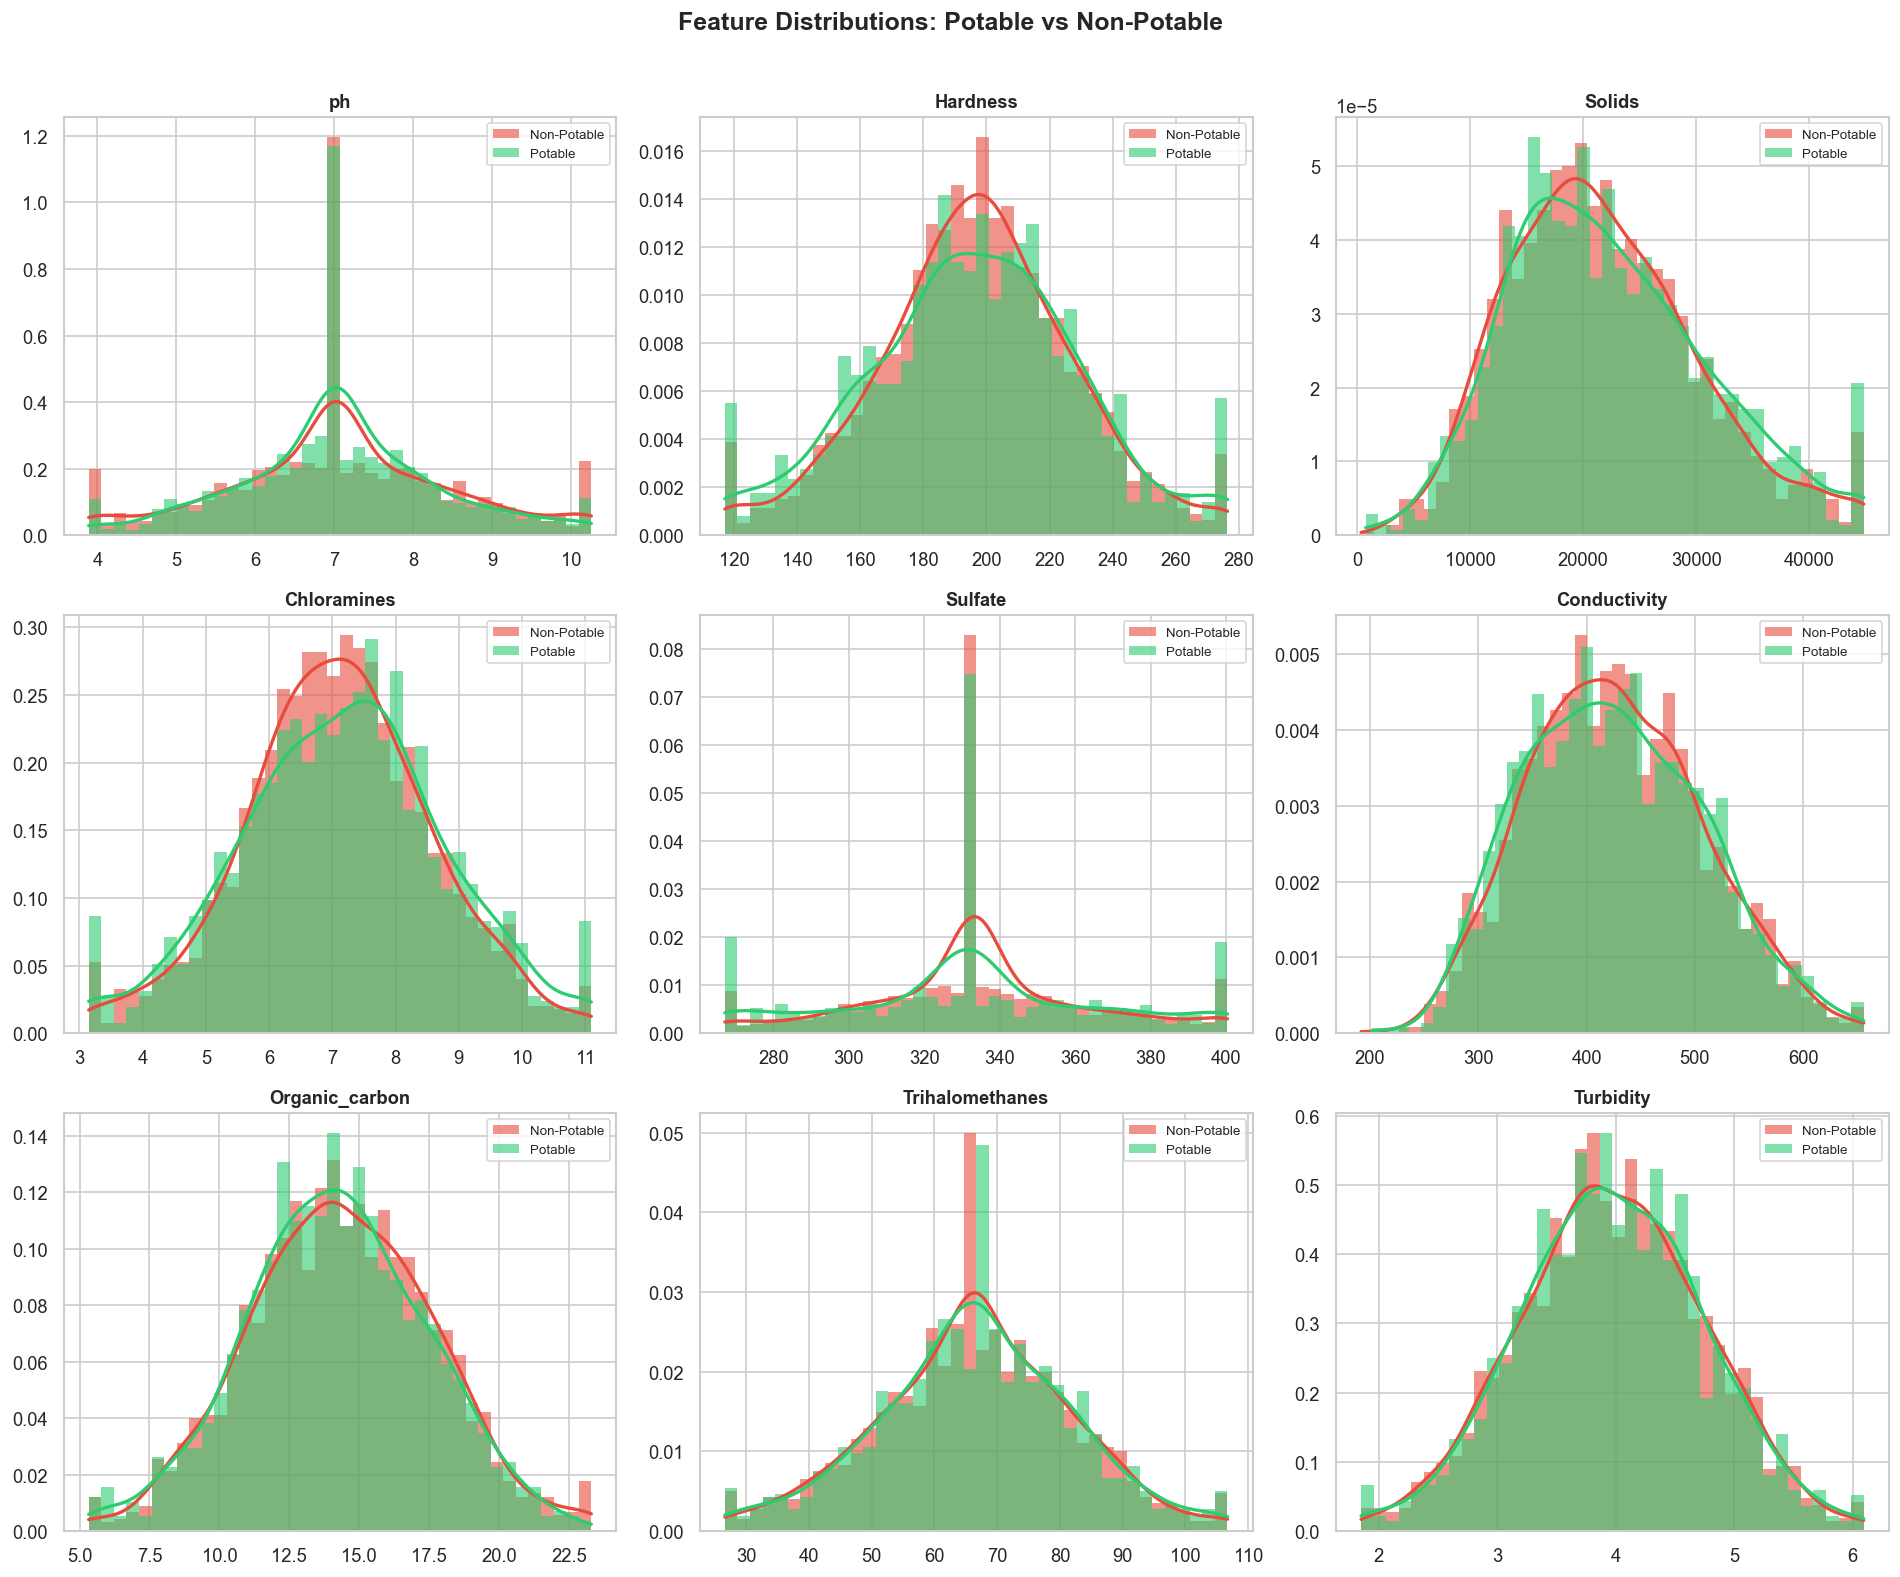

In [2]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()
colors = {'Non-Potable': '#e74c3c', 'Potable': '#2ecc71'}

for i, col in enumerate(feature_cols):
    for potability, label in [(0, 'Non-Potable'), (1, 'Potable')]:
        subset = df[df['Potability'] == potability][col]
        axes[i].hist(subset, bins=40, alpha=0.6, color=colors[label],
                     label=label, edgecolor='none', density=True)
        # KDE overlay
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(subset)
        xs = np.linspace(subset.min(), subset.max(), 200)
        axes[i].plot(xs, kde(xs), color=colors[label], linewidth=2)
    
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions: Potable vs Non-Potable', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./data/processed/eda_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

## 4.2 Correlation Heatmap

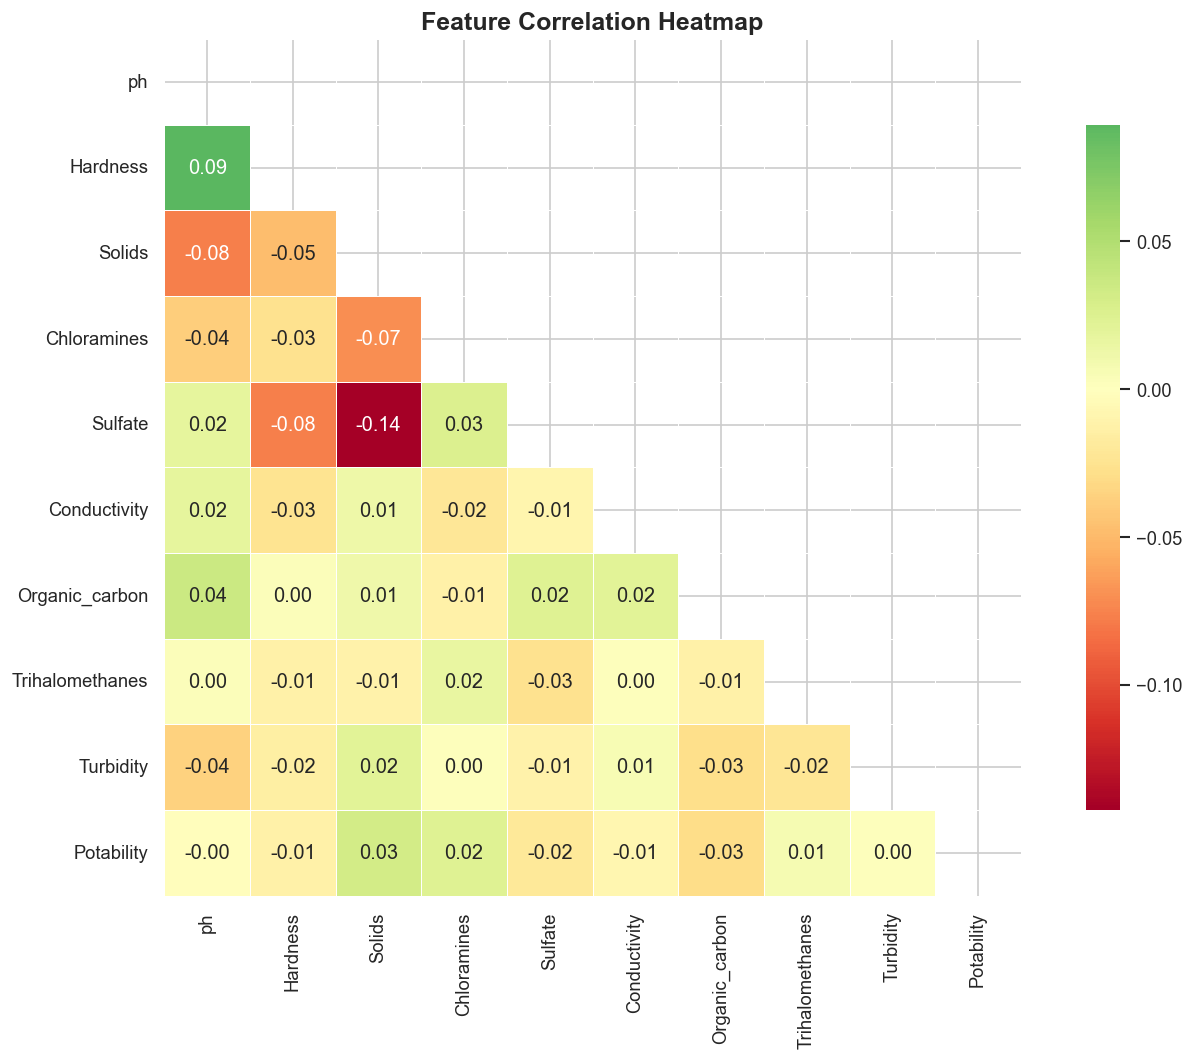

=== CORRELATION WITH POTABILITY (Target) ===
  Solids                 + (+0.0318)
  Organic_carbon         - (-0.0293)
  Chloramines            + (+0.0235)
  Sulfate                - (-0.0210)
  Hardness               - (-0.0134)
  Conductivity           - (-0.0079)
  Trihalomethanes        + (+0.0070)
  ph                     - (-0.0016)
  Turbidity              + (+0.0016)


In [ ]:
corr_matrix = df.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/eda_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

# Print correlation with target
print('CORRELATION WITH POTABILITY (Target)')
target_corr = corr_matrix['Potability'].drop('Potability').sort_values(key=abs, ascending=False)
for feat, corr in target_corr.items():
    bar = '█' * int(abs(corr) * 30)
    direction = '+' if corr > 0 else '-'
    print(f'  {feat:<22} {direction}{bar} ({corr:+.4f})')

## 4.3 Bivariate Analysis — Pairplot (Key Features)

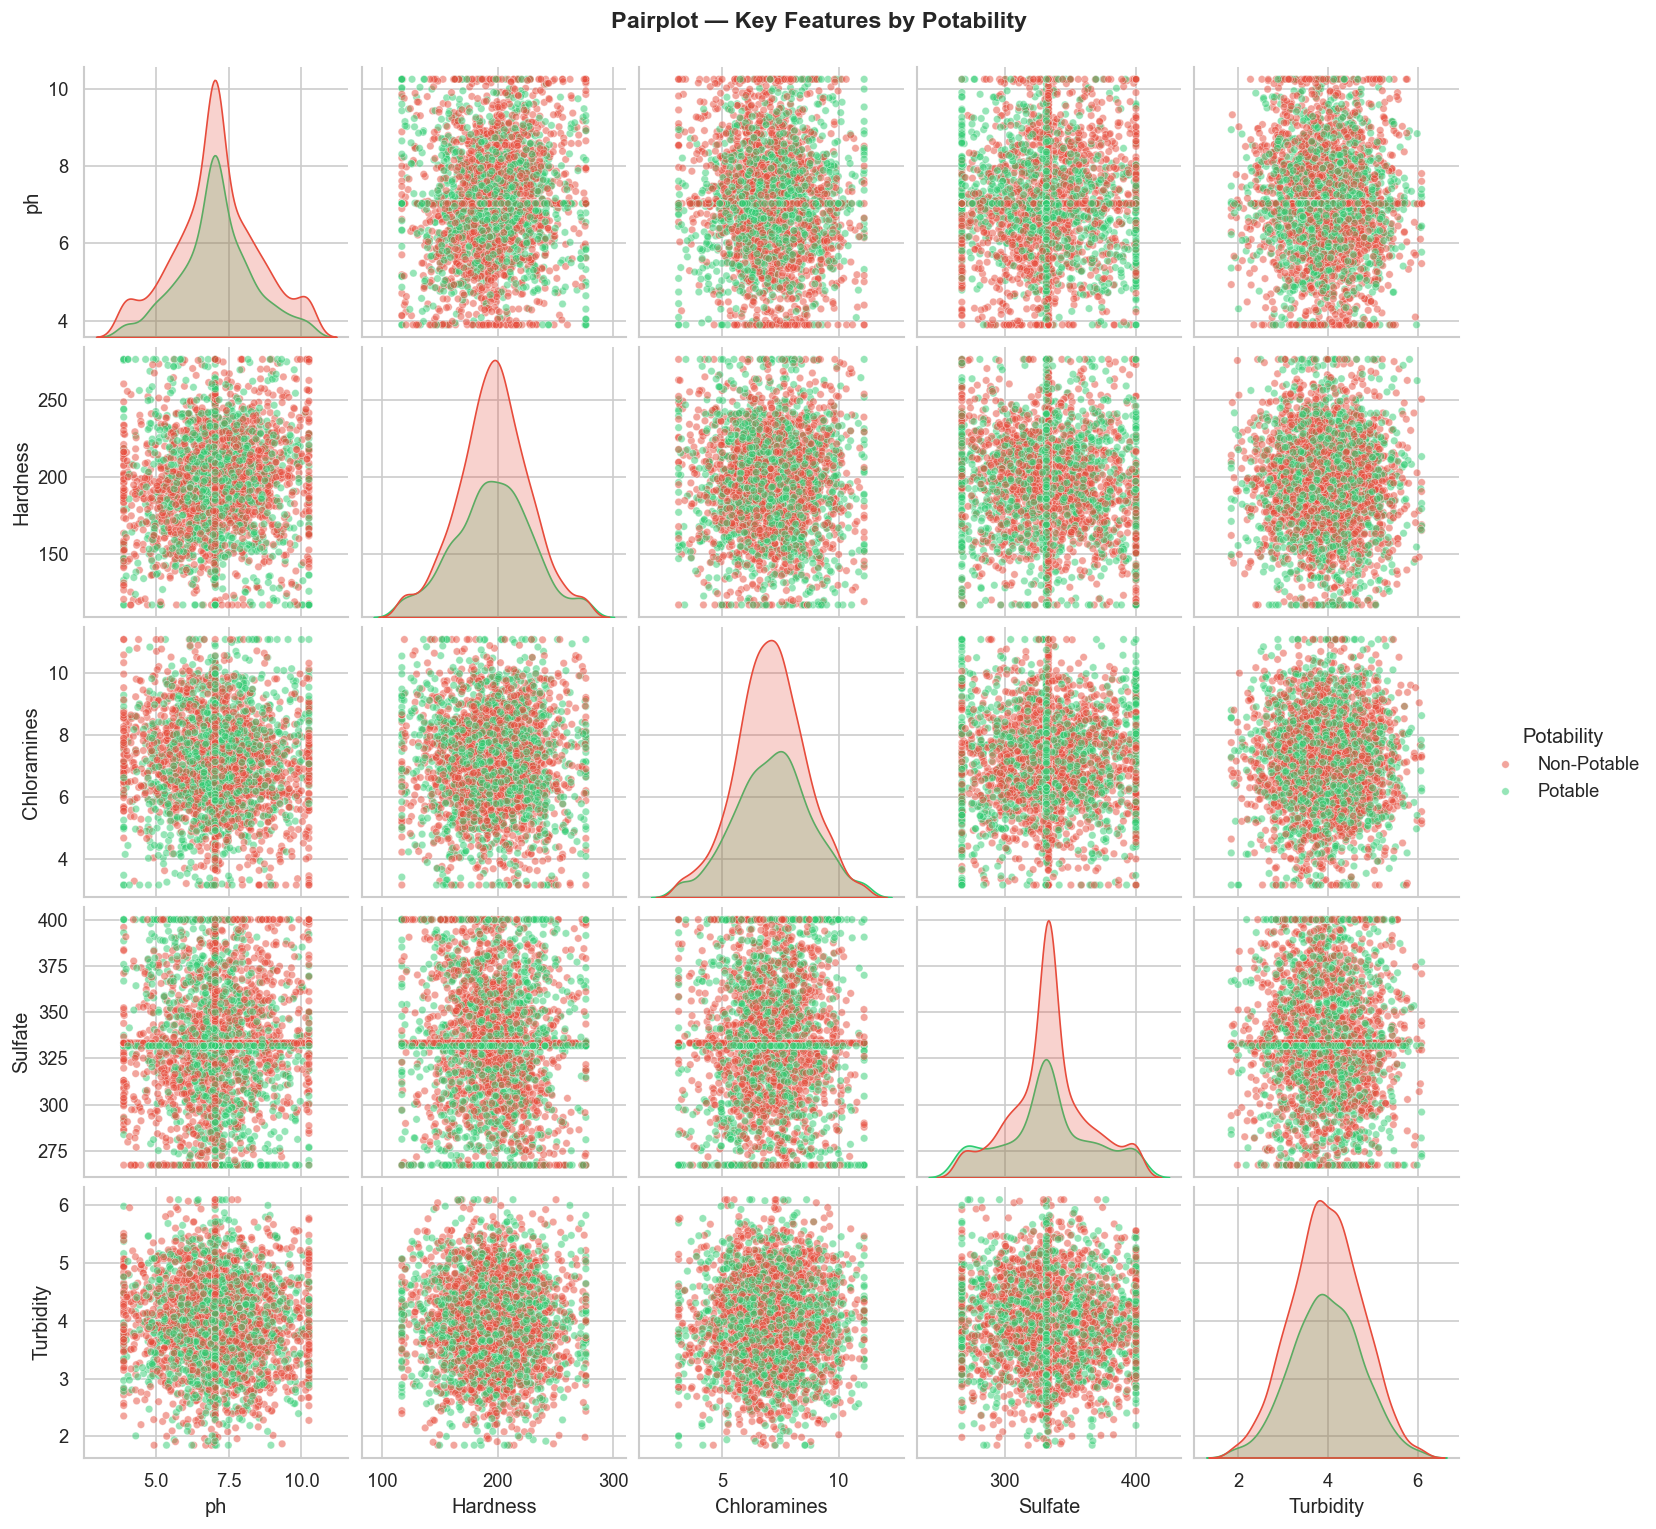

In [4]:
# Select top features for pairplot (all 9 is too dense)
top_features = ['ph', 'Hardness', 'Chloramines', 'Sulfate', 'Turbidity', 'Potability']

pair_df = df[top_features].copy()
pair_df['Potability'] = pair_df['Potability'].map({0: 'Non-Potable', 1: 'Potable'})

g = sns.pairplot(pair_df, hue='Potability',
                 palette={'Non-Potable': '#e74c3c', 'Potable': '#2ecc71'},
                 plot_kws={'alpha': 0.5, 's': 20},
                 diag_kind='kde')
g.fig.suptitle('Pairplot — Key Features by Potability', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('./data/processed/eda_pairplot.png', bbox_inches='tight', dpi=120)
plt.show()

## 4.4 Violin Plots — Class Separation per Feature

C:\Users\BAINTY KAUR\AppData\Local\Temp\ipykernel_3836\1726993665.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Potability', y=col, ax=axes[i],
C:\Users\BAINTY KAUR\AppData\Local\Temp\ipykernel_3836\1726993665.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Non-Potable', 'Potable'])
C:\Users\BAINTY KAUR\AppData\Local\Temp\ipykernel_3836\1726993665.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Potability', y=col, ax=axes[i],
C:\Users\BAINTY KAUR\AppData\Local\Temp\ipykernel_3836\1726993665.py:9: UserWarning: set_ticklabels() should only 

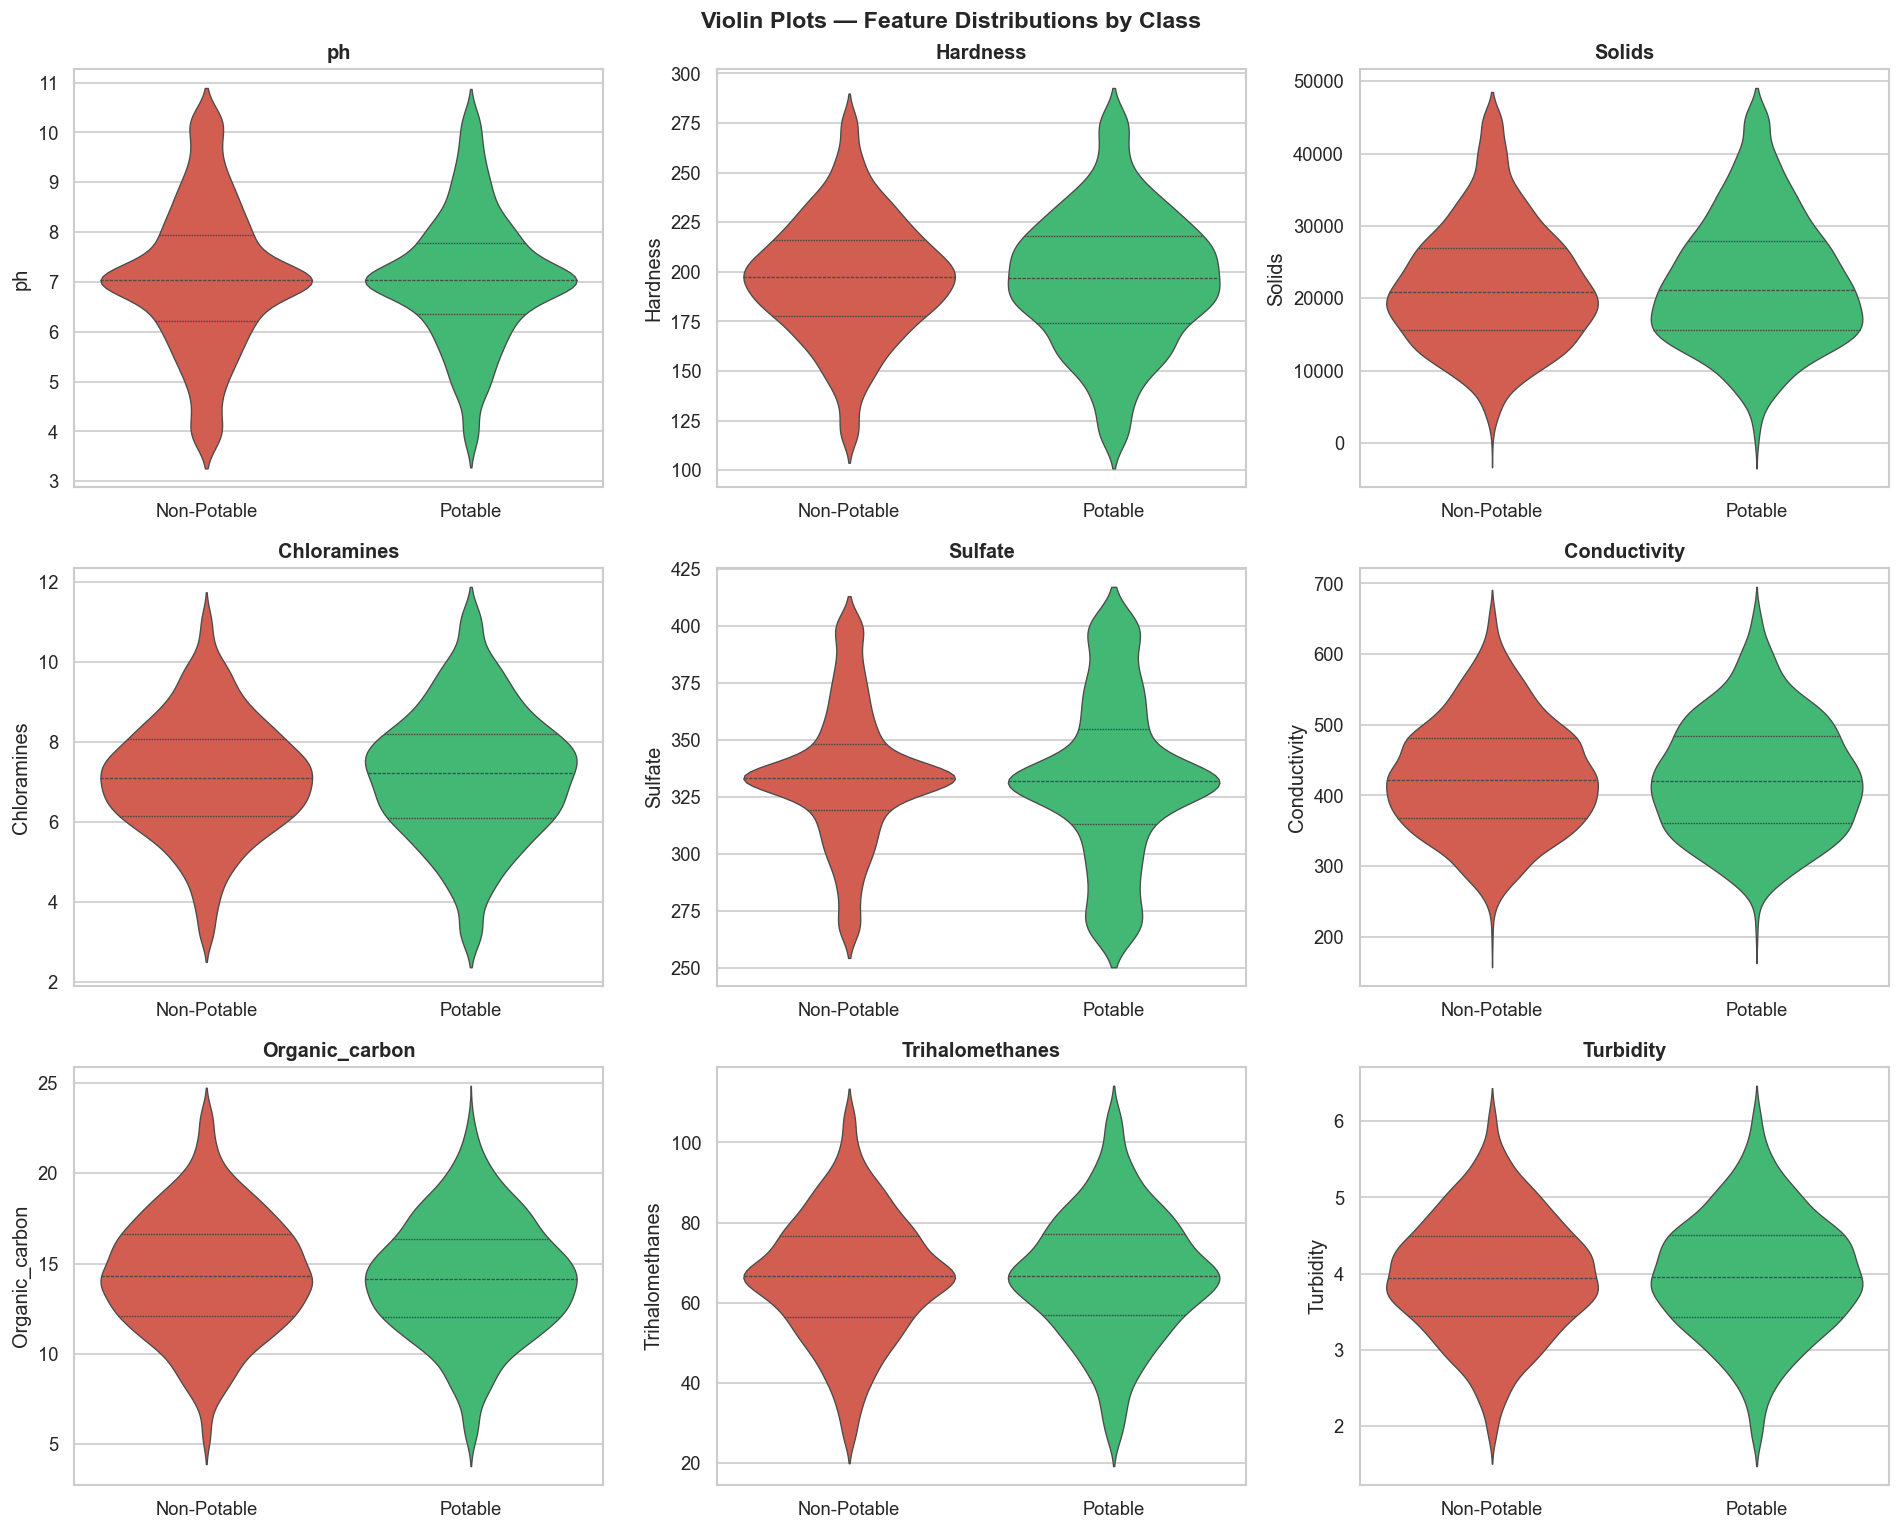

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.violinplot(data=df, x='Potability', y=col, ax=axes[i],
                   palette={'0': '#e74c3c', '1': '#2ecc71'},
                   inner='quartile', linewidth=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xticklabels(['Non-Potable', 'Potable'])
    axes[i].set_xlabel('')

plt.suptitle('Violin Plots — Feature Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/eda_violin_plots.png', bbox_inches='tight', dpi=150)
plt.show()

## 4.5 Statistical Tests — Mann-Whitney U (Non-parametric)

In [6]:
from scipy.stats import mannwhitneyu

print(f'{"Feature":<22} {"U-Statistic":>12} {"p-value":>12} {"Significant?":>14}')
print('─' * 65)

for col in feature_cols:
    group0 = df[df['Potability'] == 0][col]
    group1 = df[df['Potability'] == 1][col]
    u_stat, p_val = mannwhitneyu(group0, group1, alternative='two-sided')
    sig = '✓ YES' if p_val < 0.05 else '✗ NO'
    print(f'{col:<22} {u_stat:>12.1f} {p_val:>12.4f} {sig:>14}')

print('\n(p < 0.05 = statistically significant difference between classes)')

Feature                 U-Statistic      p-value   Significant?
─────────────────────────────────────────────────────────────────
ph                        1251045.0       0.3306           ✗ NO
Hardness                  1292727.5       0.5444           ✗ NO
Solids                    1237168.0       0.1342           ✗ NO
Chloramines               1238970.0       0.1528           ✗ NO
Sulfate                   1377043.0       0.0001          ✓ YES
Conductivity              1292413.0       0.5524           ✗ NO
Organic_carbon            1317189.0       0.1254           ✗ NO
Trihalomethanes           1265150.0       0.6612           ✗ NO
Turbidity                 1275083.0       0.9505           ✗ NO

(p < 0.05 = statistically significant difference between classes)


## 4.6 EDA Summary & Key Findings

In [7]:
print("""
╔══════════════════════════════════════════════════════════════╗
║              EDA KEY FINDINGS SUMMARY                        ║
╠══════════════════════════════════════════════════════════════╣
║  1. CLASS IMBALANCE: ~61% Non-Potable vs ~39% Potable        ║
║     → Will apply SMOTE in Stage 6                            ║
║                                                              ║
║  2. FEATURE OVERLAP: High overlap between classes for most   ║
║     features — problem is NOT linearly separable             ║
║     → Justifies ensemble methods (RF, XGB)                   ║
║                                                              ║
║  3. LOW CORRELATION WITH TARGET: All features show weak      ║
║     individual correlation (< 0.1) — complex interactions    ║
║     → Feature engineering will help (Stage 5)                ║
║                                                              ║
║  4. pH & SULFATE: Most differentiated features between       ║
║     potable and non-potable samples                          ║
║                                                              ║
║  5. NO MULTICOLLINEARITY: Features are mostly independent    ║
║     → No need to drop features before modeling               ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║              EDA KEY FINDINGS SUMMARY                        ║
╠══════════════════════════════════════════════════════════════╣
║  1. CLASS IMBALANCE: ~61% Non-Potable vs ~39% Potable        ║
║     → Will apply SMOTE in Stage 6                            ║
║                                                              ║
║  2. FEATURE OVERLAP: High overlap between classes for most   ║
║     features — problem is NOT linearly separable             ║
║     → Justifies ensemble methods (RF, XGB)                   ║
║                                                              ║
║  3. LOW CORRELATION WITH TARGET: All features show weak      ║
║     individual correlation (< 0.1) — complex interactions    ║
║     → Feature engineering will help (Stage 5)                ║
║                                                              ║
║  4. pH & SULFATE: Most differentiated features between       ║
║     potable and non-po